# Zero-One Inflated Beta Regression Analysis

This notebook implements Zero-One Inflated Beta (ZOIB) regression to study the effect of political stance and gender on divergence in comment sections.

## Why ZOIB?
- Divergence is bounded between 0 and 1
- Many observations are exactly 0 (no divergence)
- Some observations may be exactly 1 (complete divergence)
- ZOIB handles both excess zeros and excess ones simultaneously
- Models three components:
  1. Probability of being exactly 0
  2. Probability of being exactly 1
  3. Beta distribution for continuous values in (0,1)

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

## 1. Data Loading and Exploration

In [2]:
# Load the dataset
with open('post_divergence_dataset.json', 'r') as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.head()

,post_id,gender1,gender2,stance1,stance2,post_likes,post_comments,post_timestamp,verified,divergence
0,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Female,Neutral,ProChoice,247,29,2020-04-02T14:22:29.000Z,True,0.0
1,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Female,Neutral,ProLife,247,29,2020-04-02T14:22:29.000Z,True,0.0
2,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,Neutral,247,29,2020-04-02T14:22:29.000Z,True,0.0
3,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,ProChoice,247,29,2020-04-02T14:22:29.000Z,True,0.0
4,https://www.instagram.com/p/B-e08HSD5Ge/,Female,Male,Neutral,ProLife,247,29,2020-04-02T14:22:29.000Z,True,0.0


In [27]:

print(df['divergence'].describe())

print(f"\nNumber of zeros: {(df['divergence'] == 0).sum()}")
print(f"Number of ones: {(df['divergence'] == 1).sum()}")
print(f"Number in (0,1): {((df['divergence'] > 0) & (df['divergence'] < 1)).sum()}")

count    9180.000000
mean        0.187983
std         0.249522
min         0.000000
25%         0.000000
50%         0.000000
75%         0.400000
max         1.000000
Name: divergence, dtype: float64

Number of zeros: 4997
Number of ones: 125
Number in (0,1): 4058


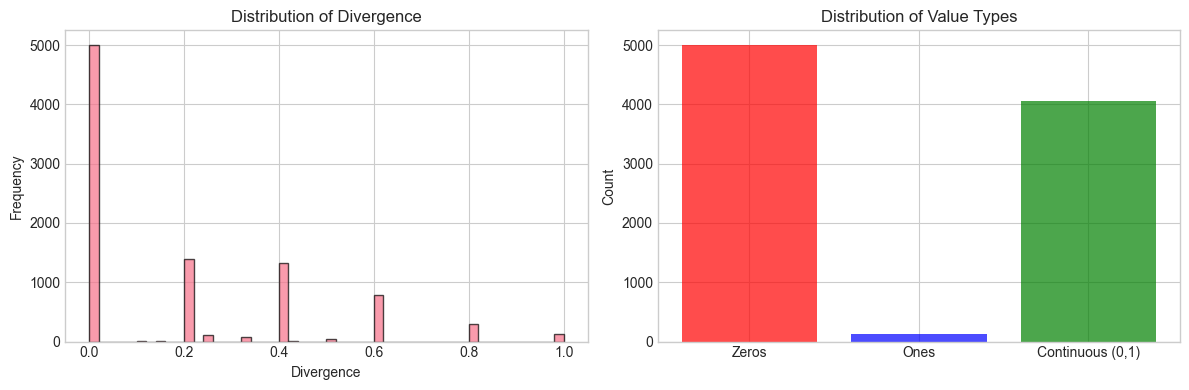

In [3]:
#  divergence distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
axes[0].hist(df['divergence'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Divergence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Divergence')

# Proportion of zeros, ones, and continuous
zeros = (df['divergence'] == 0).sum()
ones = (df['divergence'] == 1).sum()
continuous = ((df['divergence'] > 0) & (df['divergence'] < 1)).sum()

axes[1].bar(
    ['Zeros', 'Ones', 'Continuous (0,1)'], 
    [zeros, ones, continuous],
    color=['red', 'blue', 'green'], 
    alpha=0.7
)
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Value Types')

plt.tight_layout()
plt.show()

## 2. Data Preprocessing for ZOIB

In [4]:
# Create indicator variables for zeros and ones : 
df['is_zero'] = (df['divergence'] == 0).astype(int)
df['is_one'] = (df['divergence'] == 1).astype(int)
df['is_continuous'] = ((df['divergence'] > 0) & (df['divergence'] < 1)).astype(int)

# For continuous values, apply small transformation to avoid boundary issues
df['divergence_continuous'] = df['divergence'].copy()
# Squeeze values away from 0 and 1 for beta regression
epsilon = 1e-6
df.loc[df['divergence'] == 0, 'divergence_continuous'] = epsilon
df.loc[df['divergence'] == 1, 'divergence_continuous'] = 1 - epsilon

# Feature engineering

now = pd.to_datetime('now').tz_localize(None)
post_dates = pd.to_datetime(df['post_timestamp']).dt.tz_localize(None)
df['months_since_post'] = (now - post_dates).dt.days / 30
df['log_likes'] = np.log1p(df['post_likes'])
df['gender_match'] = (df['gender1'] == df['gender2']).astype(int)

# Convert stance columns to numeric before creating interaction
stance_mapping = {'Neutral': 0, 'ProChoice': 1, 'ProLife': -1}
df['stance1_numeric'] = df['stance1'].map(stance_mapping)
df['stance2_numeric'] = df['stance2'].map(stance_mapping)
df['stance_gender_interaction'] = df['stance1_numeric'] * df['gender_match']

# One-hot encode categorical variables
df = pd.get_dummies(df, columns=['stance1', 'stance2', 'gender1', 'gender2'], 
                    drop_first=True)

print("shape:", df.shape)
df.head()

shape: (9180, 22)


,post_id,post_likes,post_comments,post_timestamp,verified,divergence,is_zero,is_one,is_continuous,divergence_continuous,...,gender_match,stance1_numeric,stance2_numeric,stance_gender_interaction,stance1_ProChoice,stance1_ProLife,stance2_ProChoice,stance2_ProLife,gender1_Male,gender2_Male
0,https://www.instagram.com/p/B-e08HSD5Ge/,247,29,2020-04-02T14:22:29.000Z,True,0.0,1,0,0,0.000001,...,1,0,1,0,False,False,True,False,False,False
1,https://www.instagram.com/p/B-e08HSD5Ge/,247,29,2020-04-02T14:22:29.000Z,True,0.0,1,0,0,0.000001,...,1,0,-1,0,False,False,False,True,False,False
2,https://www.instagram.com/p/B-e08HSD5Ge/,247,29,2020-04-02T14:22:29.000Z,True,0.0,1,0,0,0.000001,...,0,0,0,0,False,False,False,False,False,True
3,https://www.instagram.com/p/B-e08HSD5Ge/,247,29,2020-04-02T14:22:29.000Z,True,0.0,1,0,0,0.000001,...,0,0,1,0,False,False,True,False,False,True
4,https://www.instagram.com/p/B-e08HSD5Ge/,247,29,2020-04-02T14:22:29.000Z,True,0.0,1,0,0,0.000001,...,0,0,-1,0,False,False,False,True,False,True


## 3. Zero-One Inflated Beta Regression Implementation

We'll implement ZOIB using a three-component approach:
1. **Zero-inflation component**: Logistic regression for P(Y=0)
2. **One-inflation component**: Logistic regression for P(Y=1)
3. **Beta component**: Beta regression for continuous values in (0,1)

In [5]:
# Define features for each component :

feature_cols = ['months_since_post', 'log_likes', 'gender_match', 'stance_gender_interaction']


# Add one-hot encoded columns :

stance_cols = [col for col in df.columns if col.startswith('political_stance_')]
commenter_gender_cols = [col for col in df.columns if col.startswith('commenter_gender_')]
author_gender_cols = [col for col in df.columns if col.startswith('author_gender_')]

all_features = feature_cols + stance_cols + commenter_gender_cols + author_gender_cols
all_features = [col for col in all_features if col in df.columns]

print(f"Using {len(all_features)} features: {all_features}")

Using 4 features: ['months_since_post', 'log_likes', 'gender_match', 'stance_gender_interaction']


In [6]:
# modeling:
X = df[all_features].copy()
X = sm.add_constant(X)

# Target variables
y_zero = df['is_zero']
y_one = df['is_one']
y_continuous = df['divergence_continuous']

# Split data
X_train, X_test, y_zero_train, y_zero_test, y_one_train, y_one_test, y_cont_train, y_cont_test = train_test_split(
    X, y_zero, y_one, y_continuous, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 7344
Test set size: 1836


### 3.1 Zero-Inflation Component (Logistic Regression for P(Y=0))

In [7]:
# Fit logistic regression for zero-inflation
zero_model = sm.Logit(y_zero_train, X_train).fit(disp=0)
print("Zero-Inflation Component Results:")
print(zero_model.summary())

Zero-Inflation Component Results:
                           Logit Regression Results                           
Dep. Variable:                is_zero   No. Observations:                 7344
Model:                          Logit   Df Residuals:                     7339
Method:                           MLE   Df Model:                            4
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.3844
Time:                        20:13:22   Log-Likelihood:                -3116.0
converged:                       True   LL-Null:                       -5061.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         1.5645      0.114     13.731      0.000       1.341       1.788
months_since_post             0.1926      0.007     

In [8]:
# Evaluate zero component : 
y_zero_pred_prob = zero_model.predict(X_test)
y_zero_pred = (y_zero_pred_prob > 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("Zero Component Evaluation:")
print(f"Accuracy: {accuracy_score(y_zero_test, y_zero_pred):.4f}")
print(f"Precision: {precision_score(y_zero_test, y_zero_pred):.4f}")
print(f"Recall: {recall_score(y_zero_test, y_zero_pred):.4f}")
print(f"F1 Score: {f1_score(y_zero_test, y_zero_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_zero_test, y_zero_pred_prob):.4f}")

Zero Component Evaluation:
Accuracy: 0.7908
Precision: 0.8428
Recall: 0.7568
F1 Score: 0.7975
ROC AUC: 0.8876


### 3.2 One-Inflation Component (Logistic Regression for P(Y=1))

In [9]:
# Fit logistic regression for one-inflation
one_model = sm.Logit(y_one_train, X_train).fit(disp=0)
print("One-Inflation Component Results:")
print(one_model.summary())

One-Inflation Component Results:
                           Logit Regression Results                           
Dep. Variable:                 is_one   No. Observations:                 7344
Model:                          Logit   Df Residuals:                     7339
Method:                           MLE   Df Model:                            4
Date:                Fri, 31 Jul 2026   Pseudo R-squ.:                  0.1943
Time:                        20:13:36   Log-Likelihood:                -422.74
converged:                       True   LL-Null:                       -524.68
Covariance Type:            nonrobust   LLR p-value:                 5.506e-43
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -6.3393      0.463    -13.688      0.000      -7.247      -5.432
months_since_post            -0.2821      0.045     -

In [10]:
# Evaluate one component
y_one_pred_prob = one_model.predict(X_test)
y_one_pred = (y_one_pred_prob > 0.5).astype(int)

print("One Component Evaluation:")
print(f"Accuracy: {accuracy_score(y_one_test, y_one_pred):.4f}")
print(f"Precision: {precision_score(y_one_test, y_one_pred):.4f}")
print(f"Recall: {recall_score(y_one_test, y_one_pred):.4f}")
print(f"F1 Score: {f1_score(y_one_test, y_one_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_one_test, y_one_pred_prob):.4f}")

One Component Evaluation:
Accuracy: 0.9858
Precision: 0.0000
Recall: 0.0000
F1 Score: 0.0000
ROC AUC: 0.9006


### 3.3 Beta Component (Beta Regression for Continuous Values)

In [11]:
# Filter to continuous values only for beta regression
continuous_mask_train = (y_cont_train > epsilon) & (y_cont_train < 1 - epsilon)
continuous_mask_test = (y_cont_test > epsilon) & (y_cont_test < 1 - epsilon)

X_cont_train = X_train[continuous_mask_train]
y_cont_train_filtered = y_cont_train[continuous_mask_train]

X_cont_test = X_test[continuous_mask_test]
y_cont_test_filtered = y_cont_test[continuous_mask_test]

print(f"Continuous training samples: {len(X_cont_train)}")
print(f"Continuous test samples: {len(X_cont_test)}")

Continuous training samples: 3247
Continuous test samples: 811


In [12]:
# Transform to logit scale for beta regression
def logit_transform(x):
    return np.log(x / (1 - x))

y_cont_train_logit = logit_transform(y_cont_train_filtered)
y_cont_test_logit = logit_transform(y_cont_test_filtered)

# Fit OLS on logit-transformed values (approximation of beta regression)
beta_model = sm.OLS(y_cont_train_logit, X_cont_train).fit()
print("Beta Component Results (Logit-transformed OLS):")
print(beta_model.summary())

Beta Component Results (Logit-transformed OLS):
                              OLS Regression Results                             
Dep. Variable:     divergence_continuous   R-squared:                       0.132
Model:                               OLS   Adj. R-squared:                  0.131
Method:                    Least Squares   F-statistic:                     123.7
Date:                   Fri, 31 Jul 2026   Prob (F-statistic):           2.05e-98
Time:                           20:13:47   Log-Likelihood:                -3835.9
No. Observations:                   3247   AIC:                             7682.
Df Residuals:                       3242   BIC:                             7712.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------

In [13]:
# Evaluate :
y_cont_pred_logit = beta_model.predict(X_cont_test)

# Transform back from logit scale
def inverse_logit(x):
    return 1 / (1 + np.exp(-x))

y_cont_pred = inverse_logit(y_cont_pred_logit)

# Clip to valid range :
y_cont_pred = np.clip(y_cont_pred, epsilon, 1 - epsilon)

print("Beta Component Evaluation:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_cont_test_filtered, y_cont_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_cont_test_filtered, y_cont_pred):.4f}")
print(f"R²: {r2_score(y_cont_test_filtered, y_cont_pred):.4f}")

Beta Component Evaluation:
RMSE: 0.1746
MAE: 0.1430
R²: 0.1096


## 4. Combined ZOIB Predictions

In [14]:

def zoib_predict(X, zero_model, one_model, beta_model):
    """Generate predictions from ZOIB model"""
    # Get probabilities
    p_zero = zero_model.predict(X)
    p_one = one_model.predict(X)
    
    # Get continuous prediction
    y_cont_logit = beta_model.predict(X)
    y_cont = inverse_logit(y_cont_logit)
    y_cont = np.clip(y_cont, epsilon, 1 - epsilon)
    
    # Normalize probabilities
    p_continuous = 1 - p_zero - p_one
    p_continuous = np.clip(p_continuous, 0, 1)
    
    # Expected value
    y_pred = p_zero * 0 + p_one * 1 + p_continuous * y_cont
    
    return y_pred, p_zero, p_one, p_continuous, y_cont

y_test_pred, p_zero_test, p_one_test, p_cont_test, y_cont_test_pred = zoib_predict(
    X_test, zero_model, one_model, beta_model
)

print("Combined ZOIB Model Evaluation:")
print(f"RMSE: {np.sqrt(mean_squared_error(y_cont_test, y_test_pred)):.4f}")
print(f"MAE: {mean_absolute_error(y_cont_test, y_test_pred):.4f}")
print(f"R²: {r2_score(y_cont_test, y_test_pred):.4f}")

Combined ZOIB Model Evaluation:
RMSE: 0.1868
MAE: 0.1294
R²: 0.4428


## 5. Feature Importance and Interpretation

In [15]:
# Extract coefficients from all components
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Zero_Component': zero_model.params,
    'One_Component': one_model.params,
    'Beta_Component': beta_model.params
})

# Calculate absolute importance
coef_df['Zero_Importance'] = np.abs(coef_df['Zero_Component'])
coef_df['One_Importance'] = np.abs(coef_df['One_Component'])
coef_df['Beta_Importance'] = np.abs(coef_df['Beta_Component'])

print("Feature Coefficients Across Components:")
coef_df

Feature Coefficients Across Components:


,Feature,Zero_Component,One_Component,Beta_Component,Zero_Importance,One_Importance,Beta_Importance
const,const,1.564527,-6.339310,-1.319598,1.564527,6.339310,1.319598
months_since_post,months_since_post,0.192629,-0.282094,-0.028785,0.192629,0.282094,0.028785
log_likes,log_likes,-0.471139,0.466397,0.137412,0.471139,0.466397,0.137412
gender_match,gender_match,0.197361,-0.637411,-0.133336,0.197361,0.637411,0.133336
stance_gender_interaction,stance_gender_interaction,0.110168,0.523287,-0.010138,0.110168,0.523287,0.010138


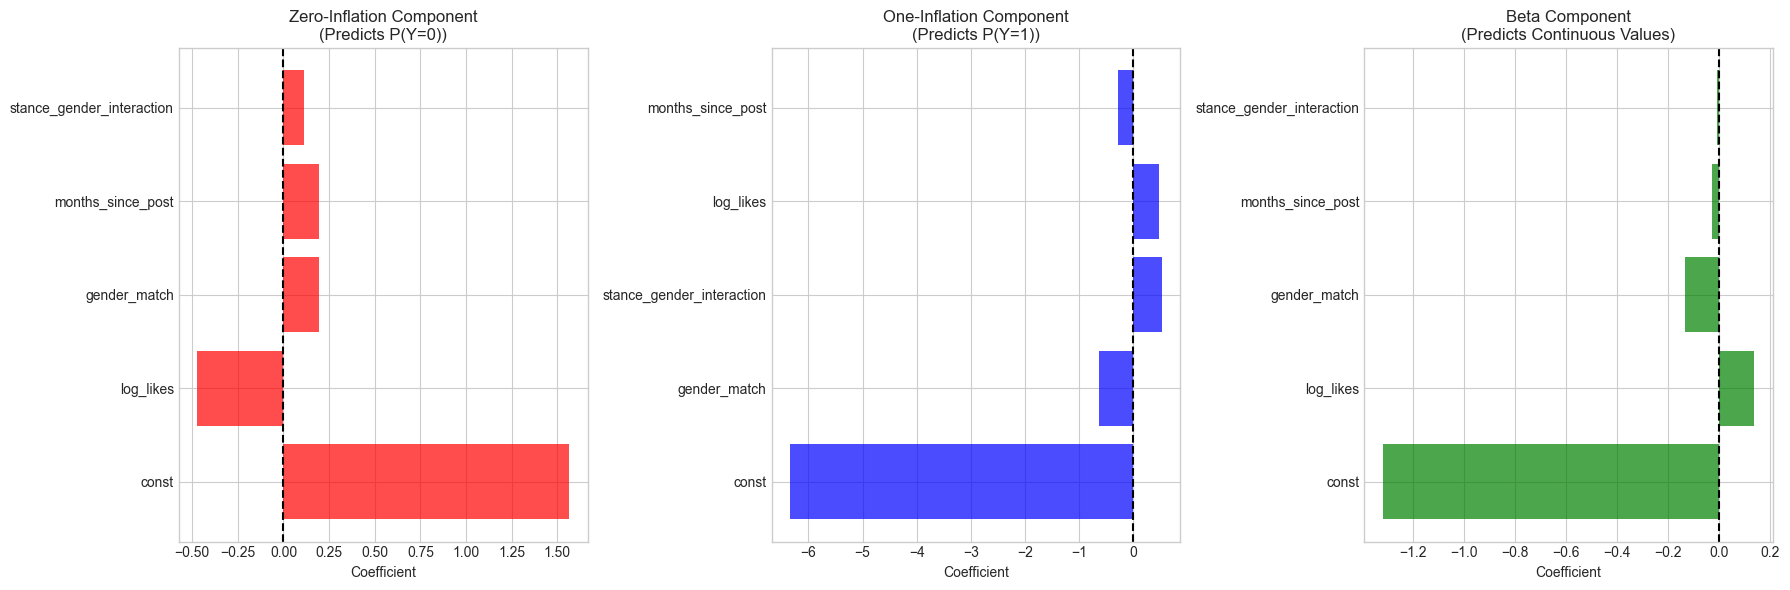

In [16]:
# Visualize feature importance for each component
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Zero component
coef_zero = coef_df.sort_values('Zero_Importance', ascending=False).head(10)
axes[0].barh(coef_zero['Feature'], coef_zero['Zero_Component'], color='red', alpha=0.7)
axes[0].set_xlabel('Coefficient')
axes[0].set_title('Zero-Inflation Component\n(Predicts P(Y=0))')
axes[0].axvline(x=0, color='black', linestyle='--')

# One component
coef_one = coef_df.sort_values('One_Importance', ascending=False).head(10)
axes[1].barh(coef_one['Feature'], coef_one['One_Component'], color='blue', alpha=0.7)
axes[1].set_xlabel('Coefficient')
axes[1].set_title('One-Inflation Component\n(Predicts P(Y=1))')
axes[1].axvline(x=0, color='black', linestyle='--')

# Beta component
coef_beta = coef_df.sort_values('Beta_Importance', ascending=False).head(10)
axes[2].barh(coef_beta['Feature'], coef_beta['Beta_Component'], color='green', alpha=0.7)
axes[2].set_xlabel('Coefficient')
axes[2].set_title('Beta Component\n(Predicts Continuous Values)')
axes[2].axvline(x=0, color='black', linestyle='--')

plt.tight_layout()
plt.show()

## 6. Stance × Gender Interaction Analysis

In [17]:

if 'stance_gender_interaction' in coef_df['Feature'].values:
    interaction_coef = coef_df[coef_df['Feature'] == 'stance_gender_interaction']
    print("Stance × Gender Interaction Effect:")
    print(interaction_coef[['Feature', 'Zero_Component', 'One_Component', 'Beta_Component']])
    
    print("\nInterpretation:")
    print(f"- Zero component: Higher interaction increases P(divergence=0) by {interaction_coef['Zero_Component'].values[0]:.4f}")
    print(f"- One component: Higher interaction increases P(divergence=1) by {interaction_coef['One_Component'].values[0]:.4f}")
    print(f"- Beta component: Higher interaction increases continuous divergence by {interaction_coef['Beta_Component'].values[0]:.4f} (logit scale)")

Stance × Gender Interaction Effect:
                                             Feature  Zero_Component  \
stance_gender_interaction  stance_gender_interaction        0.110168   

                           One_Component  Beta_Component  
stance_gender_interaction       0.523287       -0.010138  

Interpretation:
- Zero component: Higher interaction increases P(divergence=0) by 0.1102
- One component: Higher interaction increases P(divergence=1) by 0.5233
- Beta component: Higher interaction increases continuous divergence by -0.0101 (logit scale)


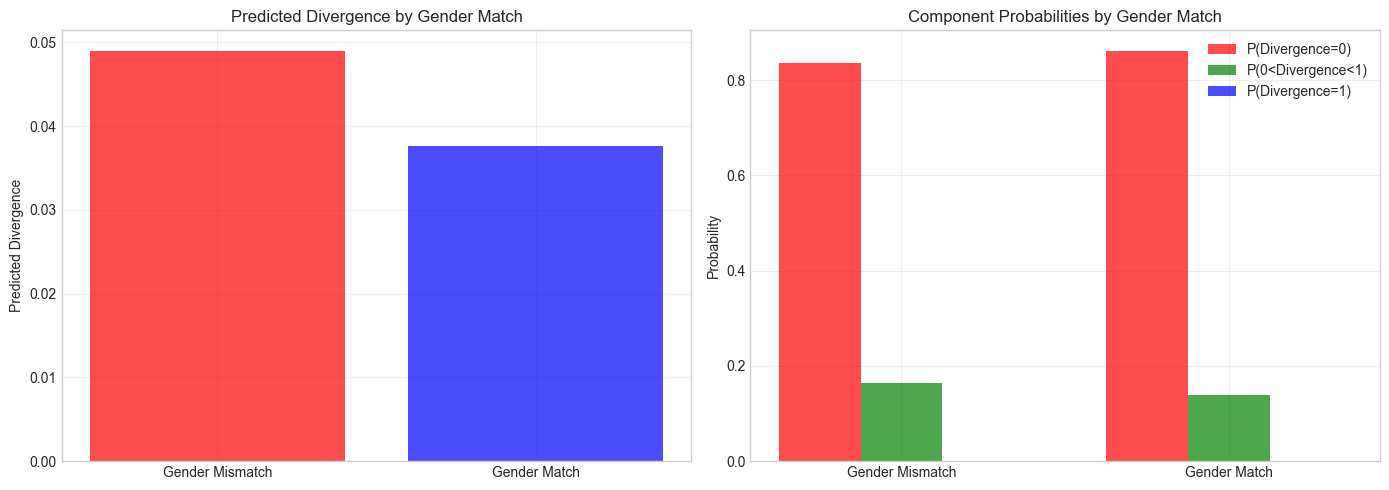

In [18]:
# Visualize predicted divergence by gender match (simplified)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Create synthetic data for visualization
gender_match_values = [0, 1]

predictions = []
for gm in gender_match_values:
    X_synthetic = X_test.mean().to_frame().T
    X_synthetic['gender_match'] = gm
    X_synthetic['stance_gender_interaction'] = 0  # Set to 0 for baseline
    
    y_pred, _, _, _, _ = zoib_predict(X_synthetic, zero_model, one_model, beta_model)
    predictions.append({'gender_match': gm, 'predicted_divergence': y_pred[0]})

pred_df = pd.DataFrame(predictions)

# Plot by gender match
axes[0].bar(pred_df['gender_match'], pred_df['predicted_divergence'], 
            color=['red', 'blue'], alpha=0.7, tick_label=['Gender Mismatch', 'Gender Match'])
axes[0].set_ylabel('Predicted Divergence')
axes[0].set_title('Predicted Divergence by Gender Match')
axes[0].grid(True, alpha=0.3)

# Component probabilities
component_preds = []
for gm in gender_match_values:
    X_synthetic = X_test.mean().to_frame().T
    X_synthetic['gender_match'] = gm
    X_synthetic['stance_gender_interaction'] = 0
    
    _, p_zero, p_one, p_cont, _ = zoib_predict(X_synthetic, zero_model, one_model, beta_model)
    component_preds.append({
        'gender_match': gm, 
        'p_zero': p_zero[0],
        'p_one': p_one[0],
        'p_cont': p_cont[0]
    })

comp_df = pd.DataFrame(component_preds)

# Plot component probabilities
x = np.arange(2)
width = 0.25
axes[1].bar(x - width, comp_df['p_zero'], width, label='P(Divergence=0)', alpha=0.7, color='red')
axes[1].bar(x, comp_df['p_cont'], width, label='P(0<Divergence<1)', alpha=0.7, color='green')
axes[1].bar(x + width, comp_df['p_one'], width, label='P(Divergence=1)', alpha=0.7, color='blue')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Gender Mismatch', 'Gender Match'])
axes[1].set_ylabel('Probability')
axes[1].set_title('Component Probabilities by Gender Match')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Conclusions and Key Insights


# ZERO-ONE INFLATED BETA REGRESSION ANALYSIS SUMMARY


## 1. DATA CHARACTERISTICS

- **Total observations:** 9,180  
- **Zeros (no divergence):** 4,997  
- **Ones (complete divergence):** 125  
- **Continuous values:** 4,058  


## 2. MODEL PERFORMANCE

- **ZOIB RMSE:** 0.1868  
- **ZOIB R²:** 0.4428